<a href="https://colab.research.google.com/github/ZarinRitu32/Dengue_ML/blob/main/02_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 · Feature Engineering & Risk Labels
**What this notebook handles.** Give the model "memory": weather lags (1–8 wk) +
trailing rolling means (3, 5 wk), **and now autoregressive case-history lags**
(`cases_lag1..4`) — the recent trajectory of cases is a strong predictor of the
next week. We also set `y_reg = log1p(cases)` and define Low/Medium/High tiers.

> Tier cut-points here are a **global** convenience for EDA and the single-split
> demos in 03–04. The leakage-safe version refits cut-points **inside each CV
> fold** in 05.

**Reads** `dengue_weekly.csv`; **writes** `features.csv`.

In [ ]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
try:
    from google.colab import drive; drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/dengue-bd'
except Exception:
    BASE = os.path.abspath('dengue-bd')
df = pd.read_csv(f'{BASE}/data/processed/dengue_weekly.csv', parse_dates=['week'])
print('Loaded', len(df), 'weeks')

Mounted at /content/drive
Loaded 139 weeks


### Build features — weather lags/rolls + case-history lags
All lags look **strictly at the past** (`shift(k)`), and rolling means use `shift(1)` first, so no feature ever peeks at the current week.

In [ ]:
# --- weather memory: lags 1-8 weeks and trailing 3/5-week rolling means ---
climate = ['rain', 'temp', 'humidity']
for col in climate:
    for k in range(1, 9):
        df[f'{col}_lag{k}'] = df[col].shift(k)          # weather k weeks ago
    for w in (3, 5):
        df[f'{col}_roll{w}'] = df[col].shift(1).rolling(w).mean()   # trailing average

# --- regression target: log1p tames the heavy right skew of case counts ---
df['y_reg'] = np.log1p(df['total_cases'])

# --- NEW: autoregressive case-history lags (recent past cases, log1p scale) ---
# These use ONLY past weeks (shift k >= 1), so they are leakage-safe.
for k in range(1, 5):
    df[f'cases_lag{k}'] = np.log1p(df['total_cases'].shift(k))

# drop the warm-up rows that have NaNs from the longest lag, then lock the matrix
df = df.dropna().reset_index(drop=True)
feat_cols = [c for c in df.columns if 'lag' in c or 'roll' in c]  # weather + case lags
print('Total features:', len(feat_cols),
      '| weather:', sum('cases' not in c for c in feat_cols),
      '| case-history:', sum('cases' in c for c in feat_cols))
print('Rows after dropna:', len(df))

Total features: 34 | weather: 30 | case-history: 4
Rows after dropna: 131


### Risk tiers (Low / Medium / High) by 33rd/67th percentile

Global thresholds: t1=175, t2=2230 cases/week


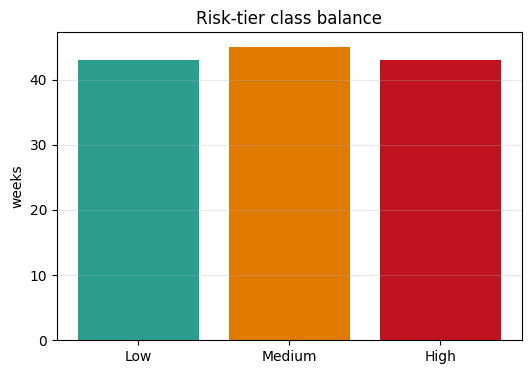

In [ ]:
t1, t2 = df['total_cases'].quantile([0.33, 0.67])
df['risk_tier'] = np.where(df['total_cases'] <= t1, 'Low',
                    np.where(df['total_cases'] <= t2, 'Medium', 'High'))
print(f'Global thresholds: t1={t1:.0f}, t2={t2:.0f} cases/week')
order = ['Low','Medium','High']; counts = df['risk_tier'].value_counts().reindex(order)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(order, counts.values, color=['#2a9d8f','#e07a00','#c1121f'])
ax.set_title('Risk-tier class balance'); ax.set_ylabel('weeks'); ax.grid(alpha=0.3, axis='y'); plt.show()

### Feature correlation (incl. case-history lags)

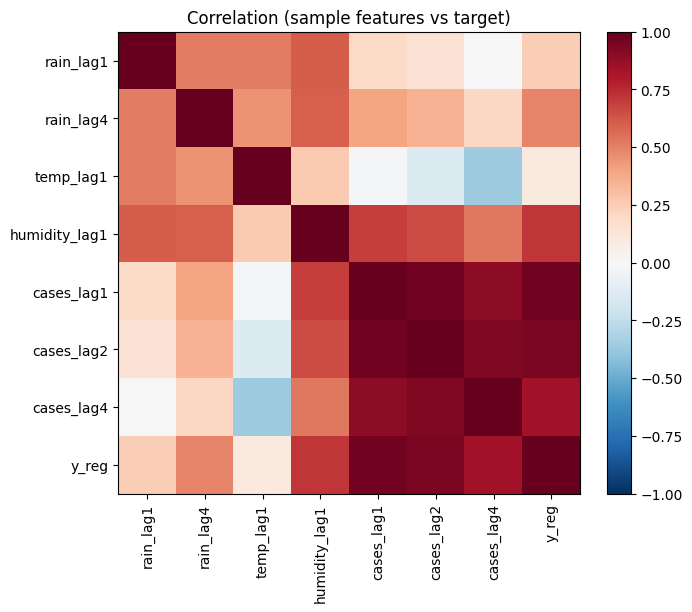

Note: cases_lag1 usually correlates strongly with y_reg — recent cases predict next week.


In [ ]:
sub = df[['rain_lag1','rain_lag4','temp_lag1','humidity_lag1',
          'cases_lag1','cases_lag2','cases_lag4','y_reg']]
corr = sub.corr()
fig, ax = plt.subplots(figsize=(7, 6)); im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
fig.colorbar(im, fraction=0.046); ax.set_title('Correlation (sample features vs target)'); plt.show()
print('Note: cases_lag1 usually correlates strongly with y_reg — recent cases predict next week.')

### Save the feature matrix

In [ ]:
out = f'{BASE}/data/processed/features.csv'
df.to_csv(out, index=False)
print('Saved', df.shape, 'to', out)
print('Targets: y_reg (regression), risk_tier (classification)')

Saved (131, 41) to /content/drive/MyDrive/dengue-bd/data/processed/features.csv
Targets: y_reg (regression), risk_tier (classification)


**Output:** `features.csv` with weather + case-history lags. Next: **03**.